# Submission Akhir: Menyelesaikan Permasalahan Institusi Pendidikan
- **Nama:** Fitria Rahmadani
- **Email:** fitriarahmadani67@gmail.com
- **ID Dicoding:** fitriara

---
## 1. Business Understanding

### Latar Belakang
Jaya Jaya Institut merupakan salah satu institusi pendidikan perguruan yang telah berdiri sejak tahun 2000. Hingga saat ini ia telah mencetak banyak lulusan dengan reputasi yang sangat baik. Akan tetapi, terdapat banyak juga siswa yang tidak menyelesaikan pendidikannya alias dropout.

Jumlah dropout yang tinggi ini tentunya menjadi salah satu masalah yang besar untuk sebuah institusi pendidikan. Oleh karena itu, Jaya Jaya Institut ingin mendeteksi secepat mungkin siswa yang mungkin akan melakukan dropout sehingga dapat diberi bimbingan khusus.

### Problem Statement
1. Tingkat dropout mahasiswa yang tinggi (~32%) berdampak negatif pada reputasi dan pendapatan institusi
2. Institusi belum memiliki sistem deteksi dini untuk mengidentifikasi mahasiswa berisiko dropout
3. Belum diketahui faktor-faktor dominan yang menyebabkan mahasiswa dropout

### Business Questions
1. Faktor apa yang paling mempengaruhi status kelulusan mahasiswa?
2. Profil mahasiswa seperti apa yang paling berisiko dropout?
3. Action apa yang dapat dilakukan institusi untuk mengurangi angka dropout?

### Goals
- Membangun model prediksi status mahasiswa (Graduate / Dropout / Enrolled) dengan akurasi tinggi
- Mengidentifikasi fitur-fitur kritis yang mempengaruhi dropout
- Menyediakan prototype aplikasi machine learning yang dapat digunakan staf akademik

---
## 2. Persiapan

### 2.1 Menyiapkan library yang dibutuhkan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)
import joblib

RANDOM_STATE = 42
print('Libraries imported successfully!')

Libraries imported successfully!


### 2.2 Menyiapkan data yang akan digunakan

In [2]:
url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/students_performance/data.csv"

df = pd.read_csv(url, sep=';', encoding='utf-8')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


---
## 3. Data Understanding

### 3.1 Deskripsi Fitur

Dataset ini berisi informasi mahasiswa dari institusi pendidikan tinggi yang mencakup data demografis, sosial-ekonomi, dan performa akademik.

| No | Fitur | Tipe | Deskripsi |
|----|-------|------|-----------|
| 1 | `Marital_status` | Kategorikal | Status pernikahan (1=Single, 2=Married, 3=Widower, 4=Divorced, 5=Facto Union, 6=Legally Separated) |
| 2 | `Application_mode` | Kategorikal | Mode pendaftaran mahasiswa |
| 3 | `Application_order` | Ordinal | Urutan pilihan program studi (0–9) |
| 4 | `Course` | Kategorikal | Kode program studi yang diambil |
| 5 | `Daytime_evening_attendance` | Biner | Waktu kuliah (1=Siang, 0=Malam) |
| 6 | `Previous_qualification` | Kategorikal | Kualifikasi pendidikan sebelumnya |
| 7 | `Previous_qualification_grade` | Numerik | Nilai kualifikasi sebelumnya (95–190) |
| 8 | `Nacionality` | Kategorikal | Kode kebangsaan mahasiswa |
| 9 | `Mothers_qualification` | Ordinal | Level pendidikan ibu |
| 10 | `Fathers_qualification` | Ordinal | Level pendidikan ayah |
| 11 | `Mothers_occupation` | Kategorikal | Pekerjaan ibu |
| 12 | `Fathers_occupation` | Kategorikal | Pekerjaan ayah |
| 13 | `Admission_grade` | Numerik | Nilai masuk (95–190) |
| 14 | `Displaced` | Biner | Apakah mahasiswa adalah pengungsi? |
| 15 | `Educational_special_needs` | Biner | Kebutuhan pendidikan khusus |
| 16 | `Debtor` | Biner | Apakah mahasiswa memiliki utang? |
| 17 | `Tuition_fees_up_to_date` | Biner | Apakah biaya kuliah sudah terbayar? |
| 18 | `Gender` | Biner | Jenis kelamin (1=Pria, 0=Wanita) |
| 19 | `Scholarship_holder` | Biner | Penerima beasiswa? |
| 20 | `Age_at_enrollment` | Numerik | Usia saat pendaftaran |
| 21 | `International` | Biner | Mahasiswa internasional? |
| 22–27 | `Curricular_units_1st_sem_*` | Numerik | Metrik akademik semester 1 (enrolled, approved, grade, dll) |
| 28–33 | `Curricular_units_2nd_sem_*` | Numerik | Metrik akademik semester 2 |
| 34 | `Unemployment_rate` | Numerik | Tingkat pengangguran nasional |
| 35 | `Inflation_rate` | Numerik | Tingkat inflasi nasional |
| 36 | `GDP` | Numerik | Pertumbuhan GDP |
| 37 | `Status` | **Target** | Status mahasiswa: Graduate / Dropout / Enrolled |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


### 3.2 Distribusi Target

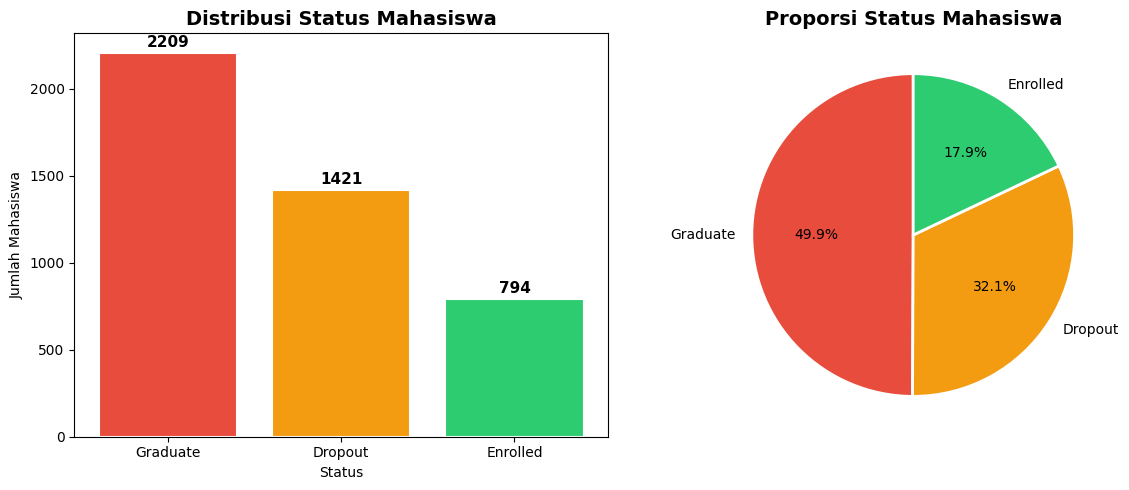


Distribusi Status:
          Count Percentage
Status                    
Graduate   2209     49.93%
Dropout    1421     32.12%
Enrolled    794     17.95%


In [5]:
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#f39c12', '#2ecc71']

axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Mahasiswa')
for i, (v, p) in enumerate(zip(status_counts.values, status_pct.values)):
    axes[0].text(i, v + 30, f'{v}', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(status_counts.values, labels=status_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDistribusi Status:')
print(pd.DataFrame({'Count': status_counts, 'Percentage': status_pct.round(2).astype(str) + '%'}))

### 3.3 Deteksi Anomali Data

#### 3.3.1 Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print('✅ Tidak ada missing values pada dataset!')
else:
    print(missing_df)

✅ Tidak ada missing values pada dataset!


#### 3.3.2 Duplikasi Data

In [7]:
dup_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')
if dup_count == 0:
    print('✅ Tidak ada data duplikat!')

Jumlah baris duplikat: 0
✅ Tidak ada data duplikat!


#### 3.3.3 Deteksi Outlier (IQR Method)

In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    if n_outliers > 0:
        outlier_summary.append({
            'Feature': col,
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outlier Count': n_outliers,
            'Outlier %': round(n_outliers / len(df) * 100, 2)
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print(f'Fitur dengan outlier: {len(outlier_df)}')
outlier_df.head(15)

Fitur dengan outlier: 28


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier %
13,Scholarship_holder,0.00,0.00,1099,24.84
26,Curricular_units_2nd_sem_grade,6.87,17.21,877,19.82
20,Curricular_units_1st_sem_grade,7.40,17.00,726,16.41
4,Previous_qualification,1.00,1.00,707,15.98
16,Curricular_units_1st_sem_credited,0.00,0.00,577,13.04
1,Application_order,-0.50,3.50,541,12.23
22,Curricular_units_2nd_sem_credited,0.00,0.00,530,11.98
12,Tuition_fees_up_to_date,1.00,1.00,528,11.93
0,Marital_status,1.00,1.00,505,11.42
11,Debtor,0.00,0.00,503,11.37


### 3.4 Univariate Analysis

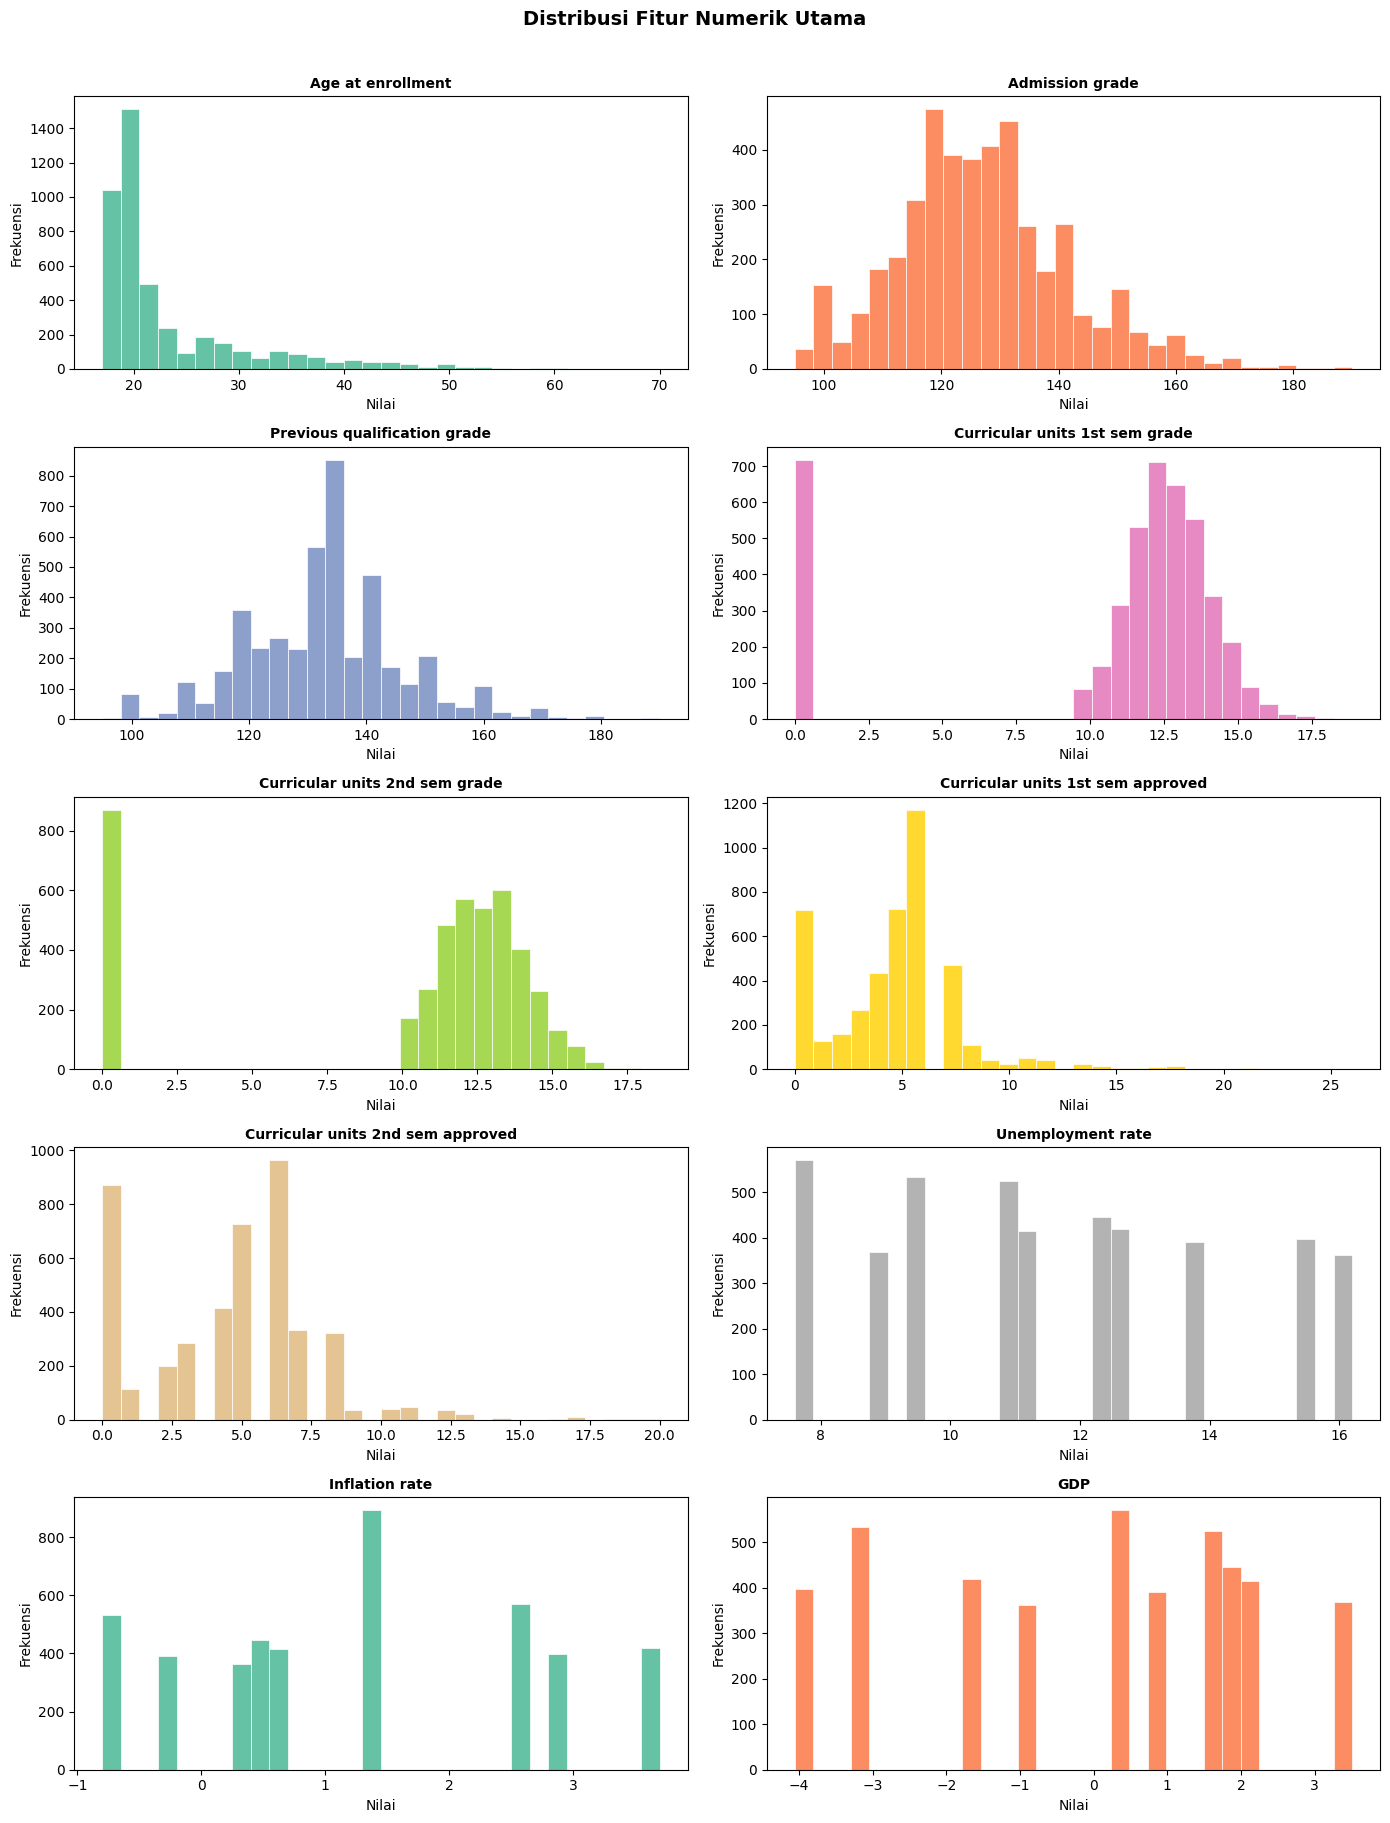

In [9]:
# Distribusi fitur numerik
num_features = ['Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
                'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
                'Unemployment_rate', 'Inflation_rate', 'GDP']

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
colors_palette = sns.color_palette('Set2', len(num_features))

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color=colors_palette[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik Utama', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

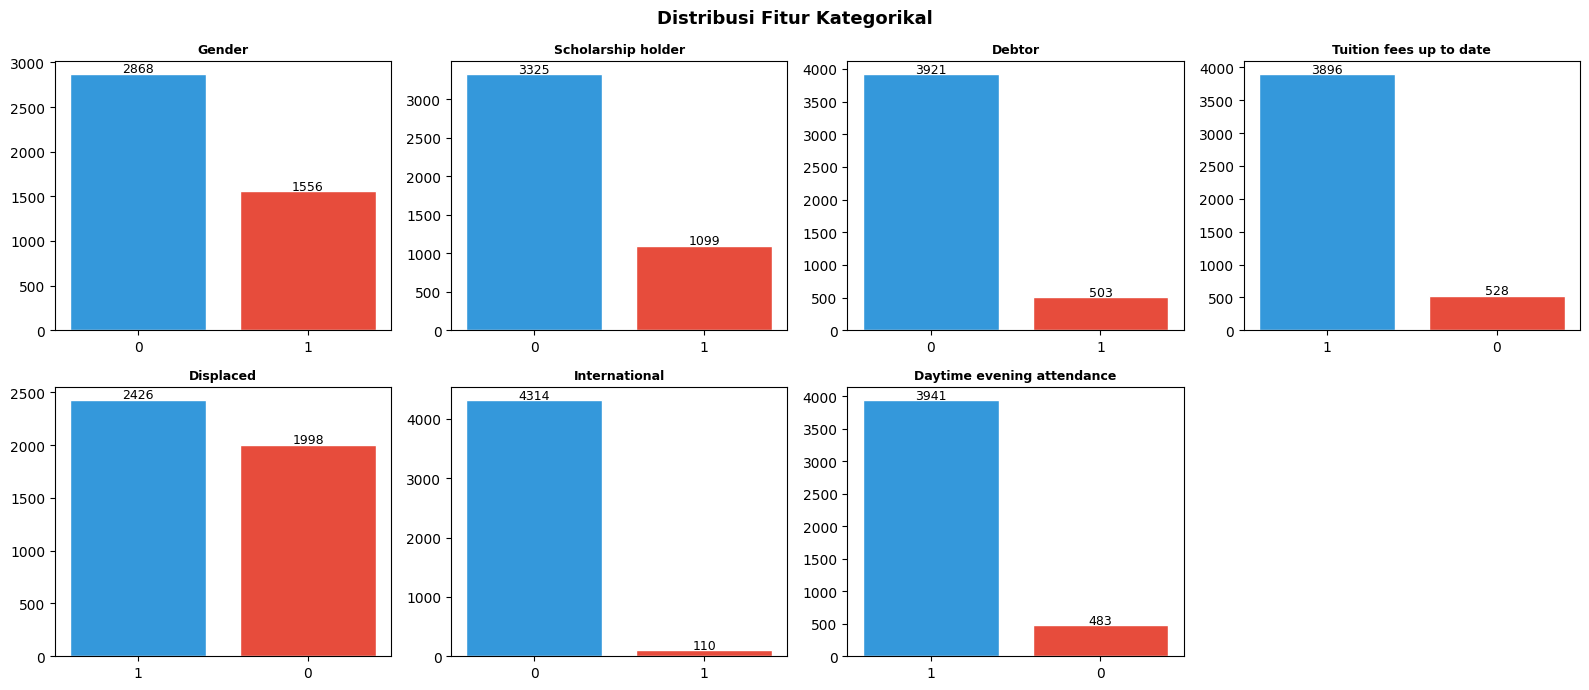

In [10]:
# Distribusi fitur kategorikal
binary_features = ['Gender', 'Scholarship_holder', 'Debtor', 'Tuition_fees_up_to_date',
                   'Displaced', 'International', 'Daytime_evening_attendance']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color=['#3498db', '#e74c3c'], edgecolor='white')
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 20, str(v), ha='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Bivariate Analysis

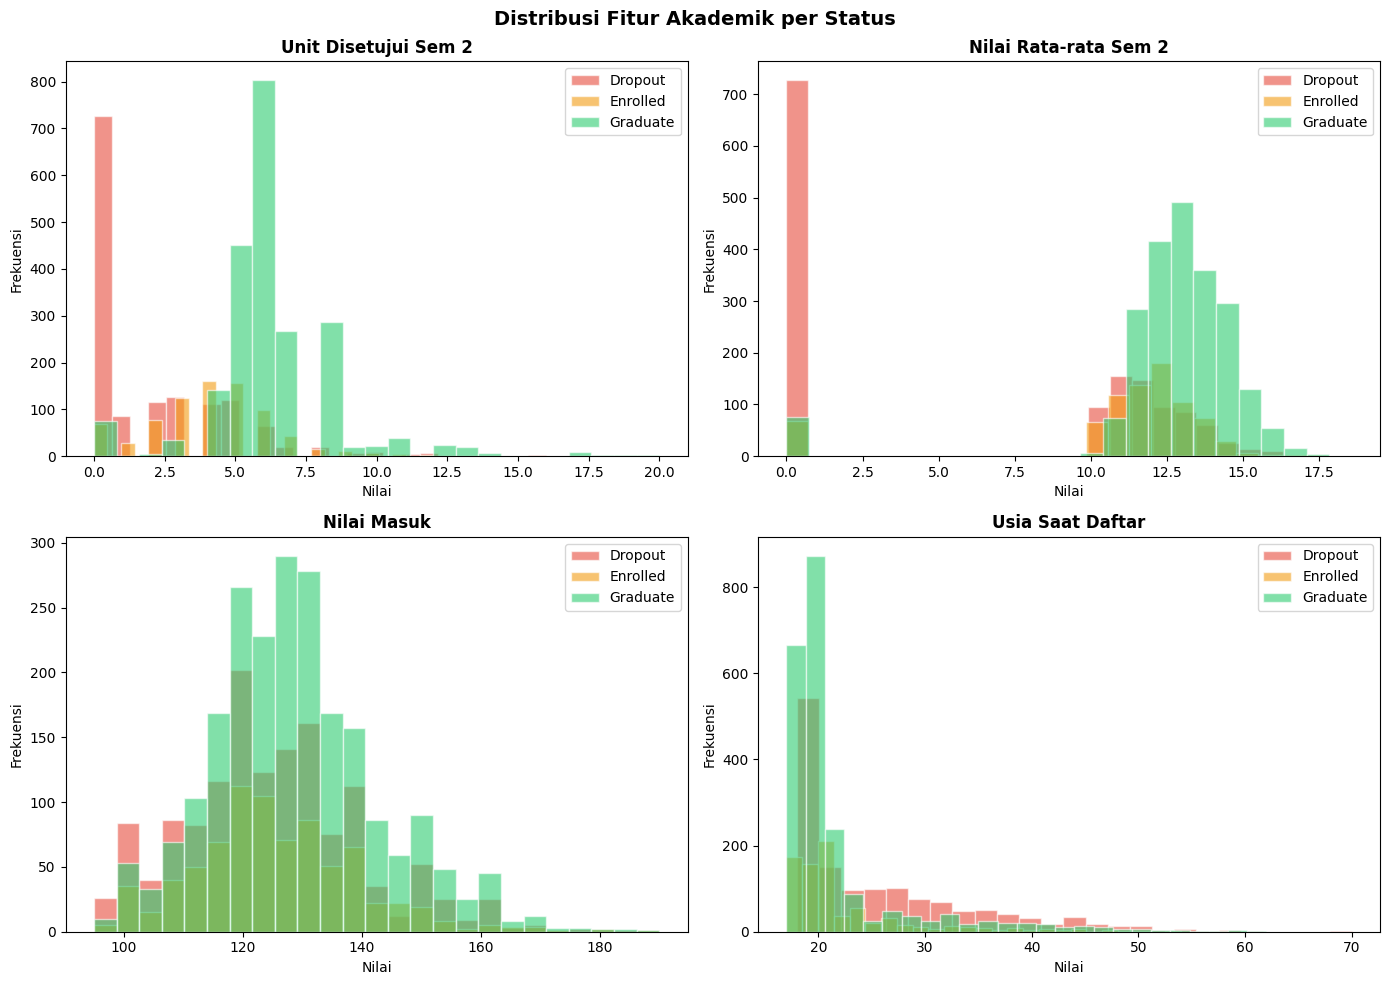

In [11]:
# Status vs fitur akademik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_map = {'Dropout': '#e74c3c', 'Enrolled': '#f39c12', 'Graduate': '#2ecc71'}

acad_features = [
    ('Curricular_units_2nd_sem_approved', 'Unit Disetujui Sem 2'),
    ('Curricular_units_2nd_sem_grade', 'Nilai Rata-rata Sem 2'),
    ('Admission_grade', 'Nilai Masuk'),
    ('Age_at_enrollment', 'Usia Saat Daftar')
]

for ax, (col, label) in zip(axes.flatten(), acad_features):
    for status, color in colors_map.items():
        subset = df[df['Status'] == status][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=status, edgecolor='white')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.suptitle('Distribusi Fitur Akademik per Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

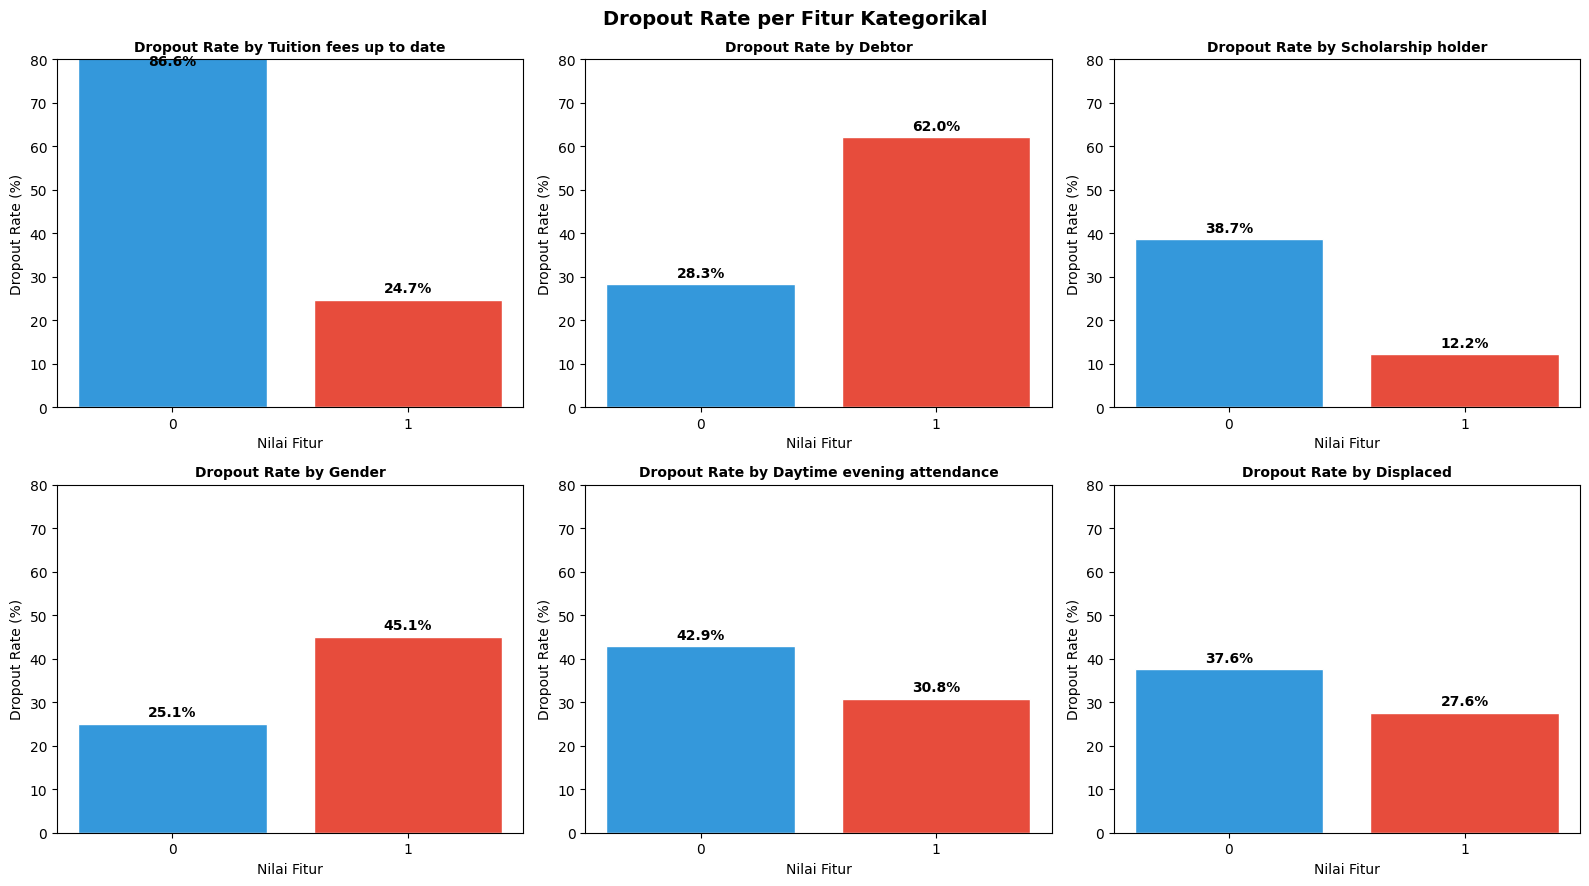

In [12]:
# Dropout rate per fitur kategorikal
cat_features = ['Tuition_fees_up_to_date', 'Debtor', 'Scholarship_holder',
                'Gender', 'Daytime_evening_attendance', 'Displaced']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    dropout_rate = df.groupby(col)['Status'].apply(lambda x: (x == 'Dropout').mean() * 100)
    bars = axes[i].bar(dropout_rate.index.astype(str), dropout_rate.values,
                       color=['#3498db', '#e74c3c'][:len(dropout_rate)], edgecolor='white')
    axes[i].set_title(f'Dropout Rate by {col.replace("_", " ")}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai Fitur')
    axes[i].set_ylabel('Dropout Rate (%)')
    axes[i].set_ylim(0, 80)

    y_max = axes[i].get_ylim()[1]

    for bar in bars:
        h = bar.get_height()
        y_pos = min(h + 1, y_max - 2)
        axes[i].text(bar.get_x() + bar.get_width()/2., y_pos,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Dropout Rate per Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Multivariate Analysis

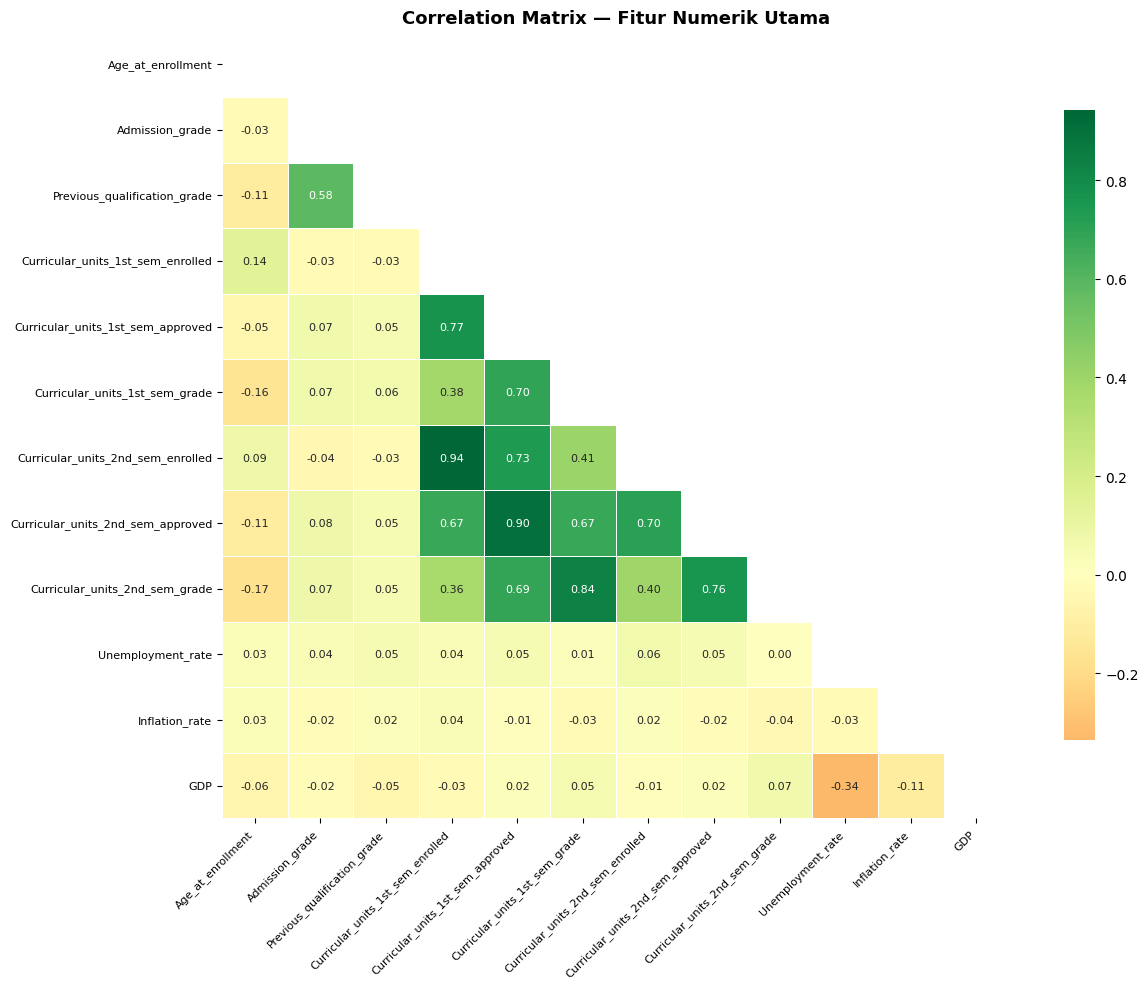

In [13]:
# Correlation heatmap fitur numerik
key_num_cols = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

corr_matrix = df[key_num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Fitur Numerik Utama', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 3.7 Insight dari EDA

1. **Target Imbalance**: Dataset tidak seimbang — Graduate (49.9%), Dropout (32.1%), Enrolled (17.9%)
2. **Performa Akademik Dominan**: Mahasiswa Dropout memiliki unit disetujui dan nilai rata-rata semester yang jauh lebih rendah
3. **Biaya Kuliah Kritis**: Mahasiswa yang belum melunasi biaya kuliah `Tuition_fees_up_to_date=0` memiliki dropout rate ~80%
4. **Debtor Berisiko Tinggi**: Mahasiswa berstatus debtor memiliki dropout rate ~60%
5. **Usia Berpengaruh**: Mahasiswa yang mendaftar di usia lebih tua cenderung lebih banyak dropout
6. **Beasiswa Protektif**: Penerima beasiswa memiliki dropout rate lebih rendah
7. **Korelasi Akademik**: Jumlah unit yang disetujui di semester 1 dan 2 berkorelasi kuat satu sama lain

---
## 4. Data Preparation / Preprocessing

### 4.1 Feature Engineering

In [14]:
df_prep = df.copy()

# Rerata performa dua semester
df_prep['Avg_approved'] = (df_prep['Curricular_units_1st_sem_approved'] +
                            df_prep['Curricular_units_2nd_sem_approved']) / 2

df_prep['Avg_grade'] = (df_prep['Curricular_units_1st_sem_grade'] +
                         df_prep['Curricular_units_2nd_sem_grade']) / 2

# Rasio SKS yang disetujui
total_enrolled = (df_prep['Curricular_units_1st_sem_enrolled'] +
                   df_prep['Curricular_units_2nd_sem_enrolled'])
total_approved = (df_prep['Curricular_units_1st_sem_approved'] +
                   df_prep['Curricular_units_2nd_sem_approved'])
df_prep['Approval_rate'] = np.where(total_enrolled > 0, total_approved / total_enrolled, 0)

# Indikator kesulitan finansial
df_prep['Financial_risk'] = (
    (1 - df_prep['Tuition_fees_up_to_date']) +
    df_prep['Debtor'] -
    df_prep['Scholarship_holder']
)

df_prep[['Avg_approved', 'Avg_grade', 'Approval_rate', 'Financial_risk']].describe()

,Avg_approved,Avg_grade,Approval_rate,Financial_risk
count,4424.000000,4424.000000,4424.000000,4424.000000
mean,4.571203,10.435514,0.679076,-0.015371
std,2.980306,4.818530,0.361945,0.730610
min,0.000000,0.000000,0.000000,-1.000000
25%,2.500000,11.000000,0.500000,0.000000
50%,5.000000,12.250000,0.833333,0.000000
75%,6.000000,13.266667,1.000000,0.000000
max,21.500000,18.283654,1.000000,2.000000


### 4.2 Encode Target dan Pisahkan Fitur

In [15]:
# Simpan clean data untuk dashboard
df_prep.to_csv('clean_data.csv', index=False)

# Hapus data dengan status Enrolled (Untuk modeling)
df_prep = df_prep[df_prep['Status'] != 'Enrolled']

# Encode target
le = LabelEncoder()
df_prep['Status_encoded'] = le.fit_transform(df_prep['Status'])

print('Mapping kelas:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df_prep.drop(['Status', 'Status_encoded'], axis=1)
y = df_prep['Status_encoded']

print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Distribusi kelas: {dict(pd.Series(y).value_counts().sort_index())}')

Mapping kelas: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}

Shape X: (3630, 40)
Shape y: (3630,)
Distribusi kelas: {0: np.int64(1421), 1: np.int64(2209)}


### 4.3 Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nDistribusi kelas training:')
print(pd.Series(y_train).value_counts())

Training set: 2904 samples
Test set:     726 samples

Distribusi kelas training:
Status_encoded
1    1767
0    1137
Name: count, dtype: int64


---
## 5. Modelling

### 5.1 Baseline Models

In [17]:
models = {
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')

    results.append({'Model': name, 'Accuracy': acc, 'F1-Weighted': f1_w, 'F1-Macro': f1_m})

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1-Weighted,F1-Macro
0,Random Forest,0.915978,0.914819,0.909588
1,XGBoost,0.903581,0.902562,0.896808


### 5.2 Perbandingan Model (Visualisasi)

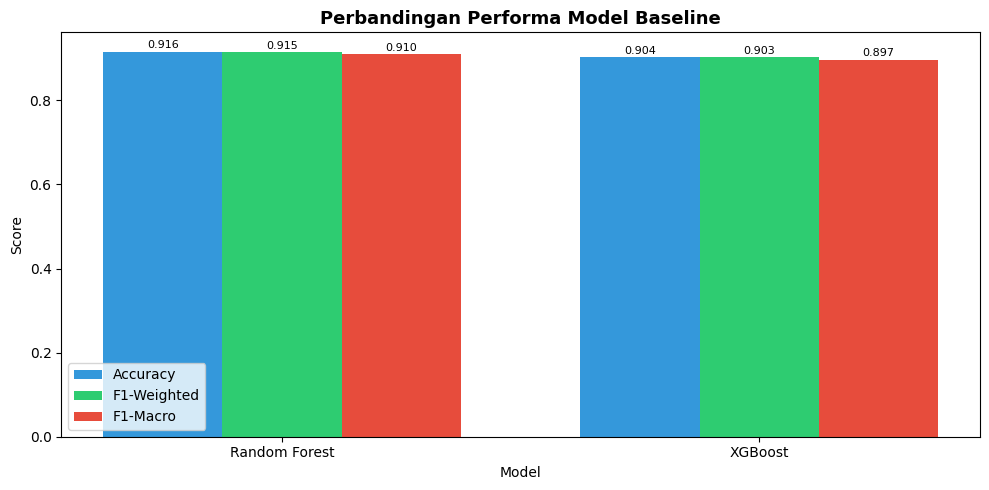

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='#3498db')
bars2 = ax.bar(x, results_df['F1-Weighted'], width, label='F1-Weighted', color='#2ecc71')
bars3 = ax.bar(x + width, results_df['F1-Macro'], width, label='F1-Macro', color='#e74c3c')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model Baseline', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 5.3 Model Terbaik: Random Forest dengan Hyperparameter Tuning

In [19]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)

y_pred_best = best_model.predict(X_test)

print('Random Forest (Tuned)')
print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'F1-Weighted: {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'F1-Macro: {f1_score(y_test, y_pred_best, average="macro"):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Random Forest (Tuned)
Accuracy: 0.9160
F1-Weighted: 0.9149
F1-Macro: 0.9097


---
## 6. Evaluation

### 6.1 Classification Report

In [20]:
print('=== CLASSIFICATION REPORT — Random Forest (Final) ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== CLASSIFICATION REPORT — Random Forest (Final) ===
              precision    recall  f1-score   support

     Dropout       0.94      0.83      0.89       284
    Graduate       0.90      0.97      0.93       442

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.91       726



### 6.2 Confusion Matrix

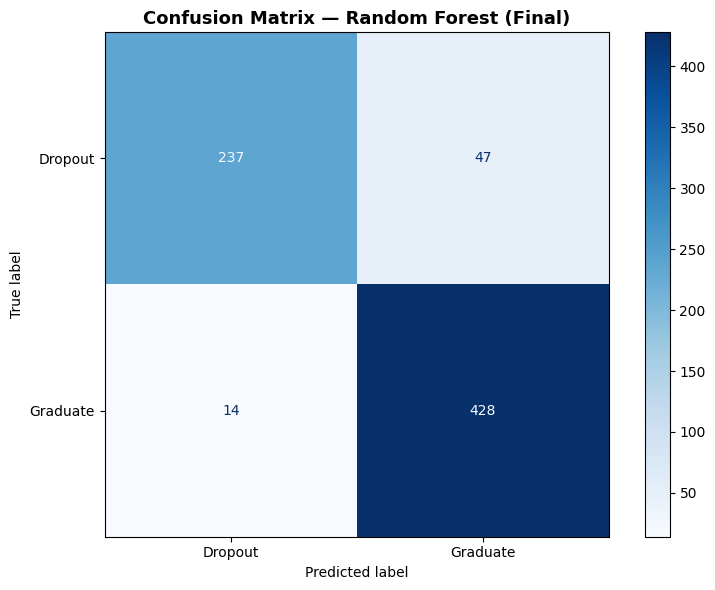

In [21]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest (Final)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Feature Importance

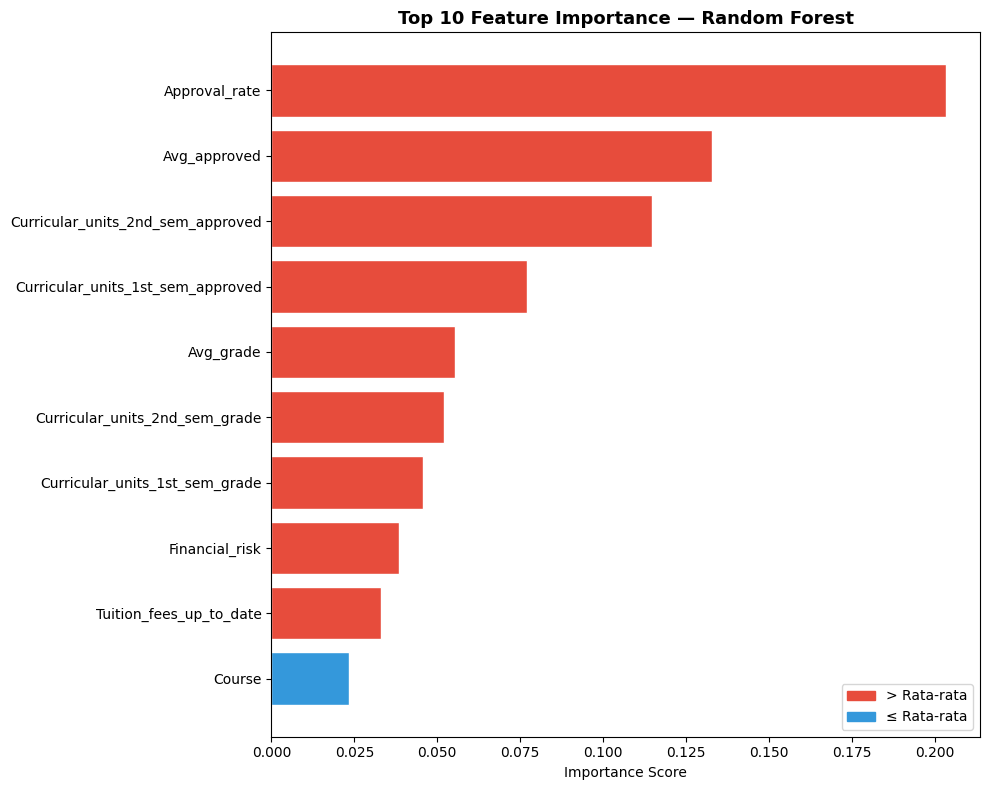


Top 10 Fitur Paling Penting:
Approval_rate                        0.203471
Avg_approved                         0.132952
Curricular_units_2nd_sem_approved    0.114803
Curricular_units_1st_sem_approved    0.077014
Avg_grade                            0.055428
Curricular_units_2nd_sem_grade       0.052122
Curricular_units_1st_sem_grade       0.045702
Financial_risk                       0.038598
Tuition_fees_up_to_date              0.033097
Course                               0.023422
dtype: float64


In [22]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if f > feat_imp.mean() else '#3498db' for f in feat_imp_sorted.values]
ax.barh(feat_imp_sorted.index, feat_imp_sorted.values, color=colors, edgecolor='white')
ax.set_title('Top 10 Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

red_patch = mpatches.Patch(color='#e74c3c', label='> Rata-rata')
blue_patch = mpatches.Patch(color='#3498db', label='≤ Rata-rata')
ax.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

print('\nTop 10 Fitur Paling Penting:')
print(feat_imp.sort_values(ascending=False).head(10))

---
## 7. Deployment

### 7.1 Simpan Model dan Artefak

In [23]:
import os
os.makedirs('model', exist_ok=True)

joblib.dump(best_model, 'model/model.joblib')
joblib.dump(le, 'model/label_encoder.joblib')

# Simpan nama fitur untuk konsistensi
import json
with open('model/features.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print('Model dan artefak berhasil disimpan!')
print(os.listdir('model/'))

Model dan artefak berhasil disimpan!
['model.joblib', 'features.json', 'label_encoder.joblib']


### 7.2 Test Prediksi

In [24]:
# Load model dan uji prediksi
loaded_model = joblib.load('model/model.joblib')
loaded_le = joblib.load('model/label_encoder.joblib')

# Ambil sample mahasiswa dari test set
sample = X_test.iloc[:5].copy()
actual = loaded_le.inverse_transform(y_test.iloc[:5].values)
predicted = loaded_le.inverse_transform(loaded_model.predict(sample))
prob = loaded_model.predict_proba(sample)

result_df = pd.DataFrame({
    'Actual': actual,
    'Predicted': predicted,
    'P(Dropout)': prob[:, 0].round(3),
    'P(Graduate)': prob[:, 1].round(3),
    'Correct': actual == predicted
})

print('Contoh Prediksi:')
result_df

Contoh Prediksi:


,Actual,Predicted,P(Dropout),P(Graduate),Correct
0,Dropout,Dropout,0.604,0.396,True
1,Graduate,Graduate,0.152,0.848,True
2,Graduate,Graduate,0.042,0.958,True
3,Graduate,Graduate,0.035,0.965,True
4,Graduate,Graduate,0.115,0.885,True


### 7.3 Ringkasan Evaluasi Final

In [25]:
print('='*55)
print('   RINGKASAN EVALUASI MODEL FINAL (Random Forest)')
print('='*55)
print(f'  Accuracy          : {accuracy_score(y_test, y_pred_best):.4f} ({accuracy_score(y_test, y_pred_best)*100:.1f}%)')
print(f'  F1-Score Weighted : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'  F1-Score Macro    : {f1_score(y_test, y_pred_best, average="macro"):.4f}')
print('='*55)

   RINGKASAN EVALUASI MODEL FINAL (Random Forest)
  Accuracy          : 0.9160 (91.6%)
  F1-Score Weighted : 0.9149
  F1-Score Macro    : 0.9097
